# **Project 2 (S005)** — Phishing Email Detector using Machine Learning

### Team 39 — G04

**Members:**
- BENAISSA Bochra  
- SAKRI Anfel
- LARMED Kahina
- NEGAB Rania
- HADBI Sarra


## Introduction

Phishing emails are one of the most common forms of cyber attacks, designed to trick users into revealing sensitive information. This project builds a machine learning pipeline to automatically detect phishing emails by analyzing their content, structure, and metadata.

The dataset used is **CEAS_08**, it contains **39,154 emails** including sender information, recipient information, date, and labels for spam/legitimate classification.

---
## Data Preprocessing
**Student:** HADBI Sarra | **Group:** 4

This section covers loading, exploring, and cleaning the raw dataset.  
The output is `cleaned_CEAS_08.csv`.

## Step 1: Load the Dataset
Import required libraries

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

load the raw dataset for initial inspection.

In [53]:
df = pd.read_csv('CEAS_08.csv', engine='python', on_bad_lines='warn')
print(f"Dataset loaded successfully")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15932\169493084.py:1: ParserWarning: Skipping line 3636: field larger than field limit (131072)

  df = pd.read_csv('CEAS_08.csv', engine='python', on_bad_lines='warn')


Dataset loaded successfully


### 1. First Look at the Data

In [55]:
df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


**Key observations:**
- The dataset contains 7 columns: `sender`, `receiver`, `date`, `subject`, `body`, `label`, and `urls`.  
- The `label` column is our target: **1 = phishing, 0 = legitimate**.  
- The `urls` column appears to be binary (0 or 1), indicating the presence of a URL in the email.

### 2. Dataset Shape

In [58]:
rows, cols = df.shape
print(f"Rows : {rows}")
print(f"Columns : {cols}")

Rows : 39153
Columns : 7


We have **39,154 emails** in total across 7 columns.

### 3. Dataset Info (Column Names & Data Types)

In [61]:
print("Dataset info:\n")
df.info()

Dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39153 entries, 0 to 39152
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39153 non-null  object
 1   receiver  38691 non-null  object
 2   date      39153 non-null  object
 3   subject   39125 non-null  object
 4   body      39153 non-null  object
 5   label     39153 non-null  int64 
 6   urls      39153 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


`date` is stored as a `object` string, it must be converted to `datetime`. We also have some missing values detected in `receiver` and `subject`. These problems will be handled later.

## Step 2: Data Description
Explore the dataset statistically and understand the distribution of classes.

### 1. Basic Statistics

In [65]:
df.describe(include='all')

,sender,receiver,date,subject,body,label,urls
count,39153,38691,39153,39125,39153,39153.000000,39153.000000
unique,24578,3693,38657,15435,39153,NaN,NaN
top,qydlqcws-iacfym@issues.apache.org,user6@gvc.ceas-challenge.cc,"Thu, 07 Aug 2008 21:38:18 -0100",CNN.com Daily Top 10,"Buck up, your troubles caused by small dimensi...",NaN,NaN
freq,462,1374,8,2930,1,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,0.557863,0.669961
std,NaN,NaN,NaN,NaN,NaN,0.496647,0.470233
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000
75%,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000


**Key observations:**
- `sender`: most senders appear only once (24578 unique values), typical of phishing campaigns using throwaway addresses (addresses created specifically for one-time use and then abandoned).
- `subject`: "CNN.com Daily Top 10" appears 2,930 times (seems like a recurring newsletter pattern).
- `body`: every email has a completely unique body.
- `label`: mean of **0.56** confirms the slight class imbalance.
- `urls`: mean of **0.67** means roughly 2 out of 3 emails contain a URL.

### 2. Class Distribution (label column)

Class Distribution:
                Count  Percentage (%)
Phishing (1)    21842           55.79
Legitimate (0)  17311           44.21


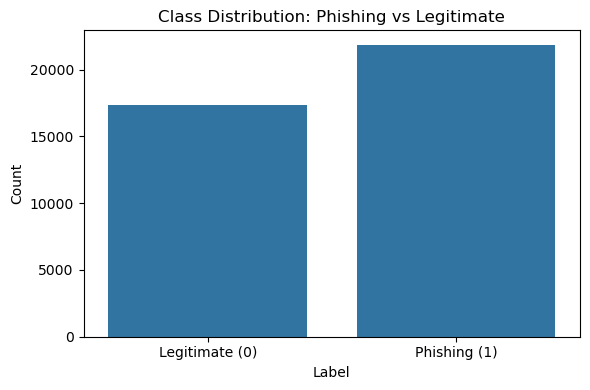

In [68]:
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct.round(2)
})
class_summary.index = ['Phishing (1)', 'Legitimate (0)']

print("Class Distribution:")
print(class_summary)

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.xticks([0, 1], ['Legitimate (0)', 'Phishing (1)'])
plt.title('Class Distribution: Phishing vs Legitimate')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

We can clearly see that he dataset is slightly **imbalanced**.

### 3. URLs Column Overview

URL Distribution:
             Count  Percentage (%)
Has URL (1)  26231            67.0
No URL (0)   12922            33.0


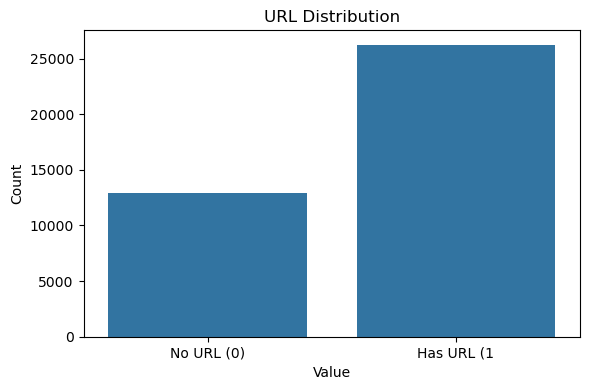

In [71]:
url_counts = df['urls'].value_counts()
url_pct = df['urls'].value_counts(normalize=True) * 100

url_summary = pd.DataFrame({
    'Count': url_counts,
    'Percentage (%)': url_pct.round(2)
})
url_summary.index = ['Has URL (1)', 'No URL (0)']

print("URL Distribution:")
print(url_summary)

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='urls', data=df)
plt.xticks([0, 1], ['No URL (0)', 'Has URL (1'])
plt.title('URL Distribution')
plt.xlabel('Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4. Check Missing Values

In [73]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print(missing_df)

          Missing Count  Missing %
sender                0       0.00
receiver            462       1.18
date                  0       0.00
subject              28       0.07
body                  0       0.00
label                 0       0.00
urls                  0       0.00


Only `receiver` and `subject` have missing values and both are **minor**. `body` and `label` are complete with no missing values, which is critical since they are the main inputs for training. Therefore, we will handle our missing values by filling `receiver` with `'unknown'` and `subject` with `'no subject'`, preserving all rows since no data is too incomplete to keep.

### 5. Check Duplicates

In [76]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")

Duplicate rows found: 0


Thus, our dataset **does not contain** any duplicate rows.

## Step 3: Data Cleaning
Handle missing values, clean the text columns and convert data types when needed.

### 1. Handle Missing Values
- `receiver`: 462 missing (1.18%) → fill with `'unknown'`
- `subject`: 28 missing (0.07%) → fill with `'no subject'`

In [80]:
df['receiver'] = df['receiver'].fillna('unknown')
df['subject']  = df['subject'].fillna('no subject')

print("Missing values handled.")
print(f"Remaining nulls:\n{df.isnull().sum()}")

Missing values handled.
Remaining nulls:
sender      0
receiver    0
date        0
subject     0
body        0
label       0
urls        0
dtype: int64


### 2. Clean Text Columns (`subject` and `body`)
The raw `body` and `subject` columns are **preserved as-is** for feature engineering,
in order to extract HTML tags, URLs, and structural features directly from them.

For text vectorization, we will create separate cleaned versions: `subject_clean` and `body_clean`

Cleaning applied:
1. Lowercase all text
2. Remove extra whitespace / newlines / tabs
3. Remove non-ASCII characters
4. Remove special characters

In [82]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove non-ASCII characters
    text = text.encode('ascii', errors='ignore').decode()
    # Remove special characters (keep letters, digits, spaces)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Remove extra whitespace / newlines / tabs
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['subject_clean'] = df['subject'].apply(clean_text)
df['body_clean']    = df['body'].apply(clean_text)

print("Clean text columns created (raw columns untouched).")
print("\nRaw body sample (first 200 chars):")
print(df['body'].iloc[2][:200])
print("\nCleaned body sample (first 200 chars):")
print(df['body_clean'].iloc[2][:200])

Clean text columns created (raw columns untouched).

Raw body sample (first 200 chars):
>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and stories as of: Aug  1, 2008  3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=

Cleaned body sample (first 200 chars):
the daily top 10 from cnn com top videos and stories as of aug 1 2008 3 58 pm edt top 10 videos 1 montauk monster http www cnn com video partners email index html url video us 2008 07 31 moos montauk 


### 3. Convert `date` to Datetime
Converting the `date` column from string to `datetime` format.

In [84]:
df_raw = df.copy()
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')

print(f"Date column converted to datetime.")
print(f"Failed conversions (NaT): {df['date'].isna().sum()}")

nat_indexes = df[df['date'].isna()].index.tolist()

print("\nFailed dates before conversion (original values):")
print(df_raw.loc[nat_indexes, 'date'])

print("\nFailed dates after conversion:")
print(df.loc[nat_indexes, 'date'])

print(f"\nSample:\n{df['date'].head()}")

Date column converted to datetime.
Failed conversions (NaT): 15

Failed dates before conversion (original values):
6278            Tue, 05 Aug   Hora oficial do Brasil
7409                      Wed, 06 Aug   ????????????
8610                      Wed, 06 Aug   ?x?_????????
9599        Wed, 06 Aug   Westeurop?ische Normalzeit
12252           Wed, 06 Aug   K?z?p-eur?pai t?li id?
13847    Wed, 06 Aug   ora solare Europa occidentale
16104             Thu, 07 Aug   ???????? ???? (????)
17579               Wed, 06 Aug   Hora padr?o de GMT
18508          Thu, 07 Aug   Jerusalem Standard Time
19435                     Thu, 07 Aug   ????????????
20208            Tue, 05 Aug   SE Asia Standard Time
22194                     Thu, 07 Aug   ????????????
24796          Thu, 07 Aug   E. Europe Daylight Time
28160     Mon, 07 Aug   rodkowoeuropejski czas letni
38797              Fri, 08 Aug   India Standard Time
Name: date, dtype: object

Failed dates after conversion:
6278    NaT
7409    NaT
8610    

The 15 failed rows have truncated date values (e.g. `"Tue, 05 Aug"` with missing time and year), making them unrecoverable. They are kept as `NaT` since their other columns (`body`, `subject`, `sender`) are intact and valuable.

### 4. Final Dataset Overview

In [87]:
print("Final cleaned dataset info:\n")
df.info()
print(f"\nFinal shape : {df.shape}")
print(f"Columns     : {list(df.columns)}")

Final cleaned dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39153 entries, 0 to 39152
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   sender         39153 non-null  object             
 1   receiver       39153 non-null  object             
 2   date           39138 non-null  datetime64[ns, UTC]
 3   subject        39153 non-null  object             
 4   body           39153 non-null  object             
 5   label          39153 non-null  int64              
 6   urls           39153 non-null  int64              
 7   subject_clean  39153 non-null  object             
 8   body_clean     39153 non-null  object             
dtypes: datetime64[ns, UTC](1), int64(2), object(6)
memory usage: 2.7+ MB

Final shape : (39153, 9)
Columns     : ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'subject_clean', 'body_clean']


### 5. Preview Cleaned Data

In [89]:
df.head()

,sender,receiver,date,subject,body,label,urls,subject_clean,body_clean
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,2008-08-05 23:31:02+00:00,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1,never agree to be a loser,buck up your troubles caused by small dimensio...
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,2008-08-05 23:31:03+00:00,Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1,befriend jenna jameson,upgrade your sex and pleasures with these tech...
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,2008-08-06 08:28:00+00:00,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,cnn com daily top 10,the daily top 10 from cnn com top videos and s...
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,2008-08-05 23:31:20+00:00,Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1,re svn commit r619753 in spamassassin trunk li...,would anyone object to removing so from this l...
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,2008-08-05 23:31:21+00:00,SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1,specialpricespharmmoreinfo,welcomefastshippingcustomersupport http 7iwfna...


## Step 4: Export Cleaned Dataset
Save the final cleaned dataset.

In [91]:
df.to_csv('cleaned_CEAS_08.csv', index=False)
print("Cleaned dataset exported as: cleaned_CEAS_08.csv")

Cleaned dataset exported as: cleaned_CEAS_08.csv


### Notes About the Cleaned Dataset — `cleaned_CEAS_08.csv`

The cleaned dataset contains **39,154 emails** across **9 columns**:

| Column | Type | Notes |
|---|---|---|
| `sender` | object | Raw, preserved for feature extraction |
| `receiver` | object | 462 missing values filled with `'unknown'` |
| `date` | datetime64 (UTC) | 15 missing values as `NaT` |
| `subject` | object | Raw, 28 missing values filled with `'no subject'` |
| `body` | object | Raw, fully intact (HTML and URLs preserved) |
| `label` | int64 | Target column: 1 = Phishing, 0 = Legitimate |
| `urls` | int64 | Binary: 1 = has URL, 0 = no URL |
| `subject_clean` | object | cleaned version of `subject` for text vectorization |
| `body_clean` | object | cleaned version of `body` for text vectorization |

**Role 2 (Feature Engineering):**
- You can drop any column you find useless.
- You can use raw `sender`, `receiver`, `body`, and `subject` for feature extraction
- `body` and `subject` retain HTML tags and URLs intentionally
- If the column `date` is used, you can  extract `hour`, `dayofweek`, and timezone directly from it. Handle the 15 `NaT` values when doing so.

**Role 3 (Text Vectorization):**
- Use `subject_clean` and `body_clean` for TF-IDF
- These columns are lowercased with special characters removed

**Role 4 (ML Engineer):**
- `label` is the target column (binary: 0 or 1)
- Dataset is slightly imbalanced (55.78% phishing, 44.22% legitimate) — consider F1-score over accuracy for evaluation
- `urls` is binary and ready to use as a feature directly

---
## Feature Engineering
**Student:** SAKRI Anfel | **Group:** 4

This section builds phishing indicators from the cleaned dataset produced by Role 1.  
Input: `cleaned_CEAS_08.csv` — Output: new feature columns saved to `featured_CEAS_08.csv`

**Features created:**
1. **URL features** — URL count, suspicious TLDs, IP-based URLs, URL length stats
2. **Keyword features** — phishing keyword hits in subject & body
3. **Structural features** — sender domain, sender/receiver mismatch, email hour/day, body length, punctuation ratios


### Setup — Import Libraries

In [95]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse

print("Libraries imported successfully.")

Libraries imported successfully.


### Load the Cleaned Dataset

In [97]:
df = pd.read_csv('cleaned_CEAS_08.csv')

# The 'date' column needs to be re-parsed as datetime after loading from CSV
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Dataset loaded: 39,153 rows × 9 columns
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'subject_clean', 'body_clean']


In [98]:
# Quick sanity check
df.head(3)

,sender,receiver,date,subject,body,label,urls,subject_clean,body_clean
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,2008-08-05 23:31:02+00:00,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1,never agree to be a loser,buck up your troubles caused by small dimensio...
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,2008-08-05 23:31:03+00:00,Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1,befriend jenna jameson,upgrade your sex and pleasures with these tech...
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,2008-08-06 08:28:00+00:00,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,cnn com daily top 10,the daily top 10 from cnn com top videos and s...


---
## Feature Group 1 — URL Detection

Phishing emails heavily rely on deceptive URLs. We extract:
- **`url_count`** : total number of URLs found in the raw body
- **`has_ip_url`** : 1 if any URL uses a raw IP address instead of a domain name (a common phishing trick)
- **`has_suspicious_tld`** : 1 if any URL ends with a known high-risk TLD (.xyz, .top, .ru, etc.)
- **`max_url_length`** : length of the longest URL (phishing URLs are often obfuscated and very long)
- **`has_url_mismatch`** : 1 if URL domain differs from the sender's domain (link spoofing)

In [100]:
# --- Configuration ---
SUSPICIOUS_TLDS = {
    '.xyz', '.top', '.ru', '.cn', '.tk', '.ml', '.ga', '.cf',
    '.gq', '.pw', '.club', '.work', '.link', '.click', '.win',
    '.online', '.site', '.info', '.biz', '.pro'
}

URL_PATTERN = re.compile(
    r'https?://[^\s<>"{}|\\^`\[\]]+',
    re.IGNORECASE
)
IP_PATTERN = re.compile(
    r'https?://(\d{1,3}\.){3}\d{1,3}',
    re.IGNORECASE
)


def extract_urls(text):
    """Return list of all URLs found in a text string."""
    if pd.isna(text):
        return []
    return URL_PATTERN.findall(str(text))


def count_urls(text):
    """Total number of URLs in the text."""
    return len(extract_urls(text))


def has_ip_url(text):
    """1 if any URL uses a raw IP address (e.g. http://192.168.1.1/login)."""
    if pd.isna(text):
        return 0
    return int(bool(IP_PATTERN.search(str(text))))


def has_suspicious_tld(text):
    """1 if any URL ends with a known high-risk TLD."""
    urls = extract_urls(text)
    for url in urls:
        try:
            domain = urlparse(url).netloc.lower()
            # Remove port number if present
            domain = domain.split(':')[0]
            for tld in SUSPICIOUS_TLDS:
                if domain.endswith(tld):
                    return 1
        except Exception:
            continue
    return 0


def max_url_length(text):
    """Length of the longest URL found (0 if none)."""
    urls = extract_urls(text)
    if not urls:
        return 0
    return max(len(u) for u in urls)


def get_sender_domain(sender):
    """Extract domain from sender field, e.g. 'John <john@gmail.com>' → 'gmail.com'."""
    if pd.isna(sender):
        return ''
    match = re.search(r'@([\w.\-]+)', str(sender))
    return match.group(1).lower() if match else ''


def has_url_mismatch(row):
    """1 if a URL in body belongs to a domain different from the sender's domain."""
    sender_domain = get_sender_domain(row['sender'])
    if not sender_domain:
        return 0
    urls = extract_urls(row['body'])
    for url in urls:
        try:
            url_domain = urlparse(url).netloc.lower().split(':')[0]
            # Strip www.
            url_domain = re.sub(r'^www\.', '', url_domain)
            sender_domain_stripped = re.sub(r'^www\.', '', sender_domain)
            if url_domain and url_domain != sender_domain_stripped:
                return 1
        except Exception:
            continue
    return 0


print("URL extraction functions defined.")

URL extraction functions defined.


In [101]:
print("Extracting URL features...")

df['url_count']          = df['body'].apply(count_urls)
df['has_ip_url']         = df['body'].apply(has_ip_url)
df['has_suspicious_tld'] = df['body'].apply(has_suspicious_tld)
df['max_url_length']     = df['body'].apply(max_url_length)
df['has_url_mismatch']   = df.apply(has_url_mismatch, axis=1)

print("URL features extracted.")
print(df[['url_count','has_ip_url','has_suspicious_tld','max_url_length','has_url_mismatch']].describe())

Extracting URL features...
URL features extracted.
          url_count    has_ip_url  has_suspicious_tld  max_url_length  \
count  39153.000000  39153.000000        39153.000000    39153.000000   
mean       3.343371      0.000690            0.010676       36.399995   
std        8.933754      0.026252            0.102773       39.424399   
min        0.000000      0.000000            0.000000        0.000000   
25%        0.000000      0.000000            0.000000        0.000000   
50%        1.000000      0.000000            0.000000       24.000000   
75%        2.000000      0.000000            0.000000       58.000000   
max      467.000000      1.000000            1.000000      307.000000   

       has_url_mismatch  
count      39153.000000  
mean           0.612469  
std            0.487193  
min            0.000000  
25%            0.000000  
50%            1.000000  
75%            1.000000  
max            1.000000  


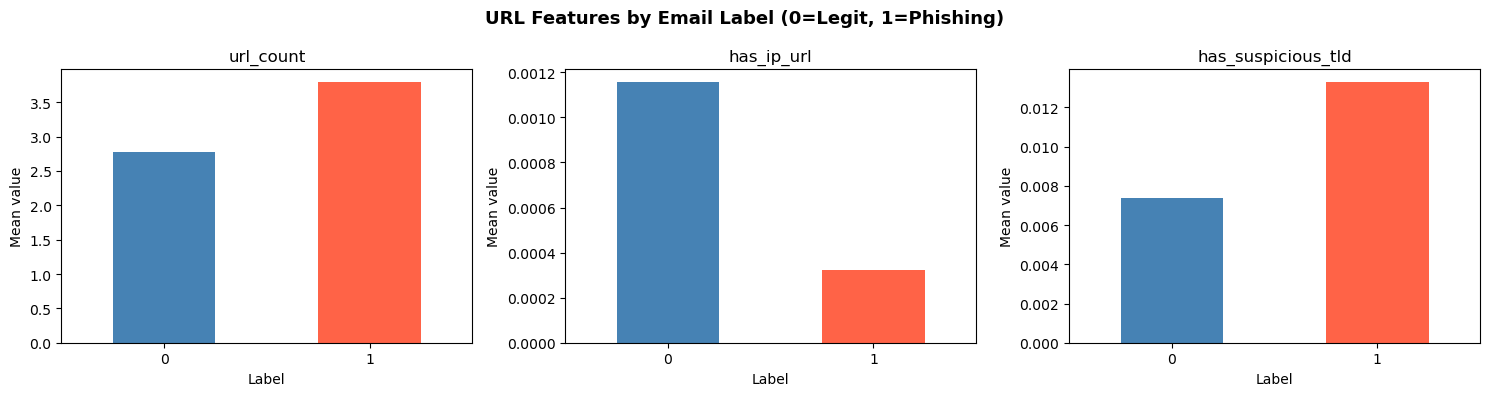

In [102]:
# Visualize URL feature distributions by label
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('URL Features by Email Label (0=Legit, 1=Phishing)', fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['url_count', 'has_ip_url', 'has_suspicious_tld']):
    df.groupby('label')[col].mean().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], rot=0)
    ax.set_title(col)
    ax.set_ylabel('Mean value')
    ax.set_xlabel('Label')

plt.tight_layout()
plt.show()

---
## Feature Group 2 — Keyword Extraction

Phishing emails use a recognizable vocabulary designed to create urgency, fear, or greed. We count how many phishing keywords appear in the subject and body:
- **`subject_keyword_hits`** : number of phishing keywords found in the subject
- **`body_keyword_hits`** : number of phishing keywords found in the body
- **`total_keyword_hits`** : combined score
- **`has_urgency_words`** : 1 if the email contains urgent-action language

In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
import numpy as np

# === DATA-DRIVEN KEYWORD EXTRACTION ===
# Extract top phishing keywords from the dataset itself using chi-squared test
# This finds words that appear significantly MORE in phishing emails vs legitimate ones

print("=" * 70)
print("EXTRACTING DATA-DRIVEN PHISHING KEYWORDS FROM DATASET")
print("=" * 70)

# Combine subject and body for keyword analysis
combined_text = df['subject_clean'].fillna('') + ' ' + df['body_clean'].fillna('')

# TF-IDF vectorization with word and 2-grams
tfidf_vectorizer = TfidfVectorizer(
    max_features=500,           # Keep top 500 features to analyze
    ngram_range=(1, 2),         # Single words + 2-word phrases
    stop_words='english',        # Remove common English words
    min_df=10                   # Word must appear in at least 10 emails
)

# Fit TF-IDF on combined text
X_tfidf = tfidf_vectorizer.fit_transform(combined_text)

# Chi-squared test: finds which words/phrases appear significantly more in phishing (label=1)
chi2_scores, p_values = chi2(X_tfidf, df['label'])

# Get feature names and sort by chi2 score (higher = more associated with phishing)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
top_indices = np.argsort(chi2_scores)[::-1][:30]  # Top 30 features

DATA_DRIVEN_KEYWORDS = [feature_names[i] for i in top_indices]

print("\n✓ TOP 30 PHISHING KEYWORDS EXTRACTED FROM DATASET (chi-squared test)")
print("-" * 70)
for i, kw in enumerate(DATA_DRIVEN_KEYWORDS, 1):
    print(f"  {i:2}. '{kw:25}' (chi2 score: {chi2_scores[top_indices[i-1]]:8.2f})")

print(f"\n✓ Dataset has {df['label'].sum()} phishing emails ({df['label'].mean()*100:.1f}%)")
print(f"  These keywords were identified as statistically significant for phishing classification.")


EXTRACTING DATA-DRIVEN PHISHING KEYWORDS FROM DATASET

✓ TOP 30 PHISHING KEYWORDS EXTRACTED FROM DATASET (chi-squared test)
----------------------------------------------------------------------
   1. 'python                   ' (chi2 score:  2633.80)
   2. 'org                      ' (chi2 score:  1536.95)
   3. 'cnn                      ' (chi2 score:  1279.03)
   4. 'wrote                    ' (chi2 score:  1197.32)
   5. 'replica                  ' (chi2 score:  1168.79)
   6. 'dev                      ' (chi2 score:   951.32)
   7. 'watches                  ' (chi2 score:   939.93)
   8. 'python org               ' (chi2 score:   936.95)
   9. 'python dev               ' (chi2 score:   855.95)
  10. 'cnn com                  ' (chi2 score:   834.83)
  11. 'opensuse                 ' (chi2 score:   783.14)
  12. 'index html               ' (chi2 score:   776.00)
  13. 'list                     ' (chi2 score:   709.71)
  14. 'perl                     ' (chi2 score:   702.39)
  15. '

In [105]:
# === HYBRID KEYWORD APPROACH ===
# Combine data-driven keywords (from dataset chi-squared) + expert curated keywords
# This ensures both statistical validity AND generalization beyond the dataset

print("\n" + "=" * 70)
print("CREATING HYBRID PHISHING KEYWORD LIST")
print("=" * 70)

# Expert-curated phishing keywords (general knowledge, from security literature)
EXPERT_CURATED_KEYWORDS = [
    # Account / Credential theft
    'validate', 'authenticate', 'verify account', 'confirm identity',
    'password', 're-enter', 'reactivate', 'suspended', 'locked',
    'verification', 'credential', 'confirm password',
    # Financial lures
    'paypal', 'wire transfer', 'prize', 'winner', 'lottery',
    'cashback', 'bitcoin', 'crypto', 'million', 'inheritance',
    'refund', 'tax return', 'payment failed',
    # Urgency / Fear tactics
    'urgent action', 'immediately', 'action required', 'limited time',
    'deadline', 'last chance', 'important notice',
    'your account will be closed', 'failure to comply',
    'act now', 'expires', 'expired',
    # Generic phishing tactics
    'click here', 'click link', 'follow link',
    'dear customer', 'dear user', 'dear member',
    'congratulations', 'chosen', 'claim reward',
    'confirm details', 'update information',
]

# Combine data-driven + expert keywords (removing duplicates)
PHISHING_KEYWORDS = list(set(DATA_DRIVEN_KEYWORDS + EXPERT_CURATED_KEYWORDS))
PHISHING_KEYWORDS.sort()

print(f"\n✓ Data-driven keywords (from dataset):  {len(DATA_DRIVEN_KEYWORDS)}")
print(f"✓ Expert-curated keywords (general):   {len(EXPERT_CURATED_KEYWORDS)}")
print(f"✓ Combined unique keywords:             {len(PHISHING_KEYWORDS)}")
print(f"\n  This hybrid approach ensures:")
print(f"  1. Keywords are VALIDATED against CEAS_08 (data-driven part)")
print(f"  2. Keywords GENERALIZE beyond the dataset (expert part)")
print(f"  3. False positives are REDUCED (only strong discriminators + general knowledge)")

URGENCY_KEYWORDS = [
    'urgent', 'immediately', 'action required', 'expire', 'expires',
    'deadline', 'last chance', 'limited time', 'act now', 'respond now',
    'failure to act', 'your account will be', 'confirm now', 'verify now',
    'expired', 'closing', 'suspended'
]


def count_keywords(text, keyword_list):
    """Count how many keywords from the list appear in text."""
    if pd.isna(text):
        return 0
    text_lower = str(text).lower()
    return sum(1 for kw in keyword_list if kw in text_lower)


def has_urgency(text):
    """1 if the text contains urgency/fear language."""
    return int(count_keywords(text, URGENCY_KEYWORDS) > 0)


print(f"\n✓ Urgency keyword list: {len(URGENCY_KEYWORDS)} keywords")
print("\nNow extracting features using hybrid keywords...")


CREATING HYBRID PHISHING KEYWORD LIST

✓ Data-driven keywords (from dataset):  30
✓ Expert-curated keywords (general):   48
✓ Combined unique keywords:             78

  This hybrid approach ensures:
  1. Keywords are VALIDATED against CEAS_08 (data-driven part)
  2. Keywords GENERALIZE beyond the dataset (expert part)
  3. False positives are REDUCED (only strong discriminators + general knowledge)

✓ Urgency keyword list: 17 keywords

Now extracting features using hybrid keywords...


In [106]:
print("Extracting keyword features...")

df['subject_keyword_hits'] = df['subject_clean'].apply(
    lambda x: count_keywords(x, PHISHING_KEYWORDS)
)
df['body_keyword_hits'] = df['body_clean'].apply(
    lambda x: count_keywords(x, PHISHING_KEYWORDS)
)
df['total_keyword_hits'] = df['subject_keyword_hits'] + df['body_keyword_hits']

# Use subject_clean + body_clean combined for urgency check
df['has_urgency_words'] = (df['subject_clean'].fillna('') + ' ' + df['body_clean'].fillna('')).apply(has_urgency)

print("Keyword features extracted.")
print(df[['subject_keyword_hits','body_keyword_hits','total_keyword_hits','has_urgency_words']].describe())

Extracting keyword features...
Keyword features extracted.
       subject_keyword_hits  body_keyword_hits  total_keyword_hits  \
count          39153.000000       39153.000000        39153.000000   
mean               0.860777           4.432278            5.293055   
std                1.162718           3.907435            4.808627   
min                0.000000           0.000000            0.000000   
25%                0.000000           1.000000            2.000000   
50%                0.000000           3.000000            4.000000   
75%                1.000000           6.000000            7.000000   
max                6.000000          23.000000           27.000000   

       has_urgency_words  
count       39153.000000  
mean            0.054632  
std             0.227263  
min             0.000000  
25%             0.000000  
50%             0.000000  
75%             0.000000  
max             1.000000  


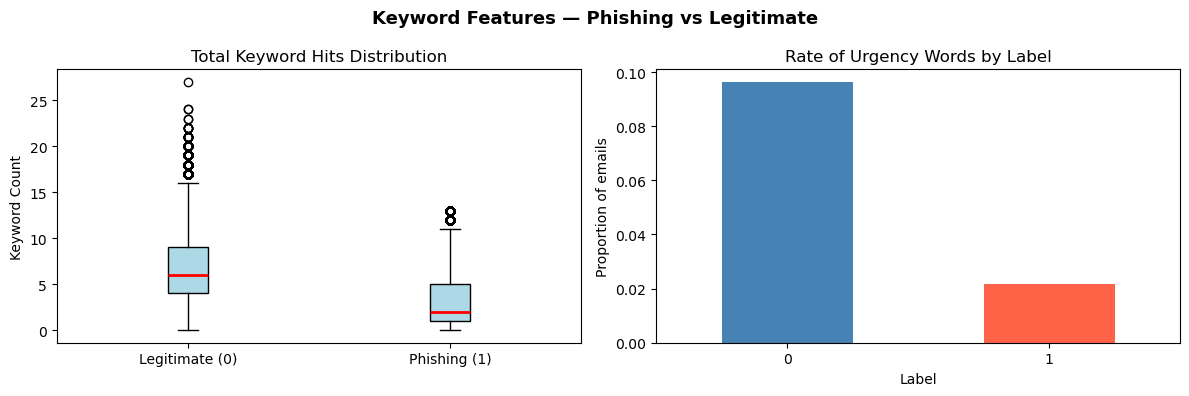

In [107]:
# Compare keyword hits between phishing and legitimate emails
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Keyword Features — Phishing vs Legitimate', fontsize=13, fontweight='bold')

# Box plot: total keyword hits
phishing = df[df['label'] == 1]['total_keyword_hits']
legit    = df[df['label'] == 0]['total_keyword_hits']
axes[0].boxplot([legit, phishing], tick_labels=['Legitimate (0)', 'Phishing (1)'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Total Keyword Hits Distribution')
axes[0].set_ylabel('Keyword Count')

# Bar chart: urgency word rate
df.groupby('label')['has_urgency_words'].mean().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], rot=0
)
axes[1].set_title('Rate of Urgency Words by Label')
axes[1].set_ylabel('Proportion of emails')
axes[1].set_xlabel('Label')

plt.tight_layout()
plt.show()

---
## Feature Group 3 — Structural Features

Beyond content, the *structure* of an email reveals phishing patterns:
- **`sender_domain`** : the domain part of the sender address
- **`sender_is_free_email`** : 1 if sender uses a free webmail provider (gmail, yahoo, hotmail…)
- **`sender_receiver_domain_match`** : 1 if sender and receiver share the same domain
- **`body_length`** : character length of raw body
- **`subject_length`** : character length of subject
- **`body_exclamation_count`** : number of '!' in body (agressive/urgent tone)
- **`body_question_count`** : number of '?' in body
- **`has_html_tags`** : 1 if body contains HTML (emails with rich HTML are more often phishing)
- **`sending_hour`** : hour of the day the email was sent (NaT → -1)
- **`sending_dayofweek`** : day of week (0=Monday … 6=Sunday, NaT → -1)

In [109]:
FREE_EMAIL_DOMAINS = {
    'gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com',
    'live.com', 'aol.com', 'icloud.com', 'protonmail.com',
    'mail.com', 'zoho.com', 'yandex.com', 'gmx.com'
}

HTML_TAG_PATTERN = re.compile(r'<[a-zA-Z][^>]*>', re.IGNORECASE)


def extract_domain(email_field):
    """Extract domain from 'Name <email@domain.com>' or plain 'email@domain.com'."""
    if pd.isna(email_field):
        return 'unknown'
    match = re.search(r'@([\w.\-]+)', str(email_field))
    return match.group(1).lower() if match else 'unknown'


def is_free_email(sender):
    """1 if sender uses a free webmail provider."""
    domain = extract_domain(sender)
    return int(domain in FREE_EMAIL_DOMAINS)


def domain_match(row):
    """1 if sender domain == receiver domain (internal email)."""
    sender_domain   = extract_domain(row['sender'])
    receiver_domain = extract_domain(row['receiver'])
    if sender_domain == 'unknown' or receiver_domain == 'unknown':
        return 0
    return int(sender_domain == receiver_domain)


def has_html(text):
    """1 if body contains HTML tags."""
    if pd.isna(text):
        return 0
    return int(bool(HTML_TAG_PATTERN.search(str(text))))


print("Structural feature functions defined.")

Structural feature functions defined.


In [110]:
print("Extracting structural features...")

# Sender / Receiver domain features
df['sender_domain']                 = df['sender'].apply(extract_domain)
df['sender_is_free_email']          = df['sender'].apply(is_free_email)
df['sender_receiver_domain_match']  = df.apply(domain_match, axis=1)

# Body / Subject length
df['body_length']    = df['body'].fillna('').apply(len)
df['subject_length'] = df['subject'].fillna('').apply(len)

# Punctuation counts in raw body
df['body_exclamation_count'] = df['body'].fillna('').apply(lambda x: str(x).count('!'))
df['body_question_count']    = df['body'].fillna('').apply(lambda x: str(x).count('?'))

# HTML presence
df['has_html_tags'] = df['body'].apply(has_html)

# Time-based features (handle the 15 NaT values with -1)
df['sending_hour']      = df['date'].apply(lambda d: d.hour      if pd.notna(d) else -1)
df['sending_dayofweek'] = df['date'].apply(lambda d: d.dayofweek if pd.notna(d) else -1)

print("Structural features extracted.")

structural_cols = [
    'sender_is_free_email', 'sender_receiver_domain_match',
    'body_length', 'subject_length',
    'body_exclamation_count', 'body_question_count',
    'has_html_tags', 'sending_hour', 'sending_dayofweek'
]
print(df[structural_cols].describe().round(2))

Extracting structural features...
Structural features extracted.
       sender_is_free_email  sender_receiver_domain_match  body_length  \
count              39153.00                      39153.00     39153.00   
mean                   0.08                          0.03      1567.44   
std                    0.27                          0.18      3543.49   
min                    0.00                          0.00        14.00   
25%                    0.00                          0.00       224.00   
50%                    0.00                          0.00       570.00   
75%                    0.00                          0.00      1643.00   
max                    1.00                          1.00    123029.00   

       subject_length  body_exclamation_count  body_question_count  \
count        39153.00                39153.00             39153.00   
mean            38.90                    0.93                 2.15   
std             20.76                    7.49             

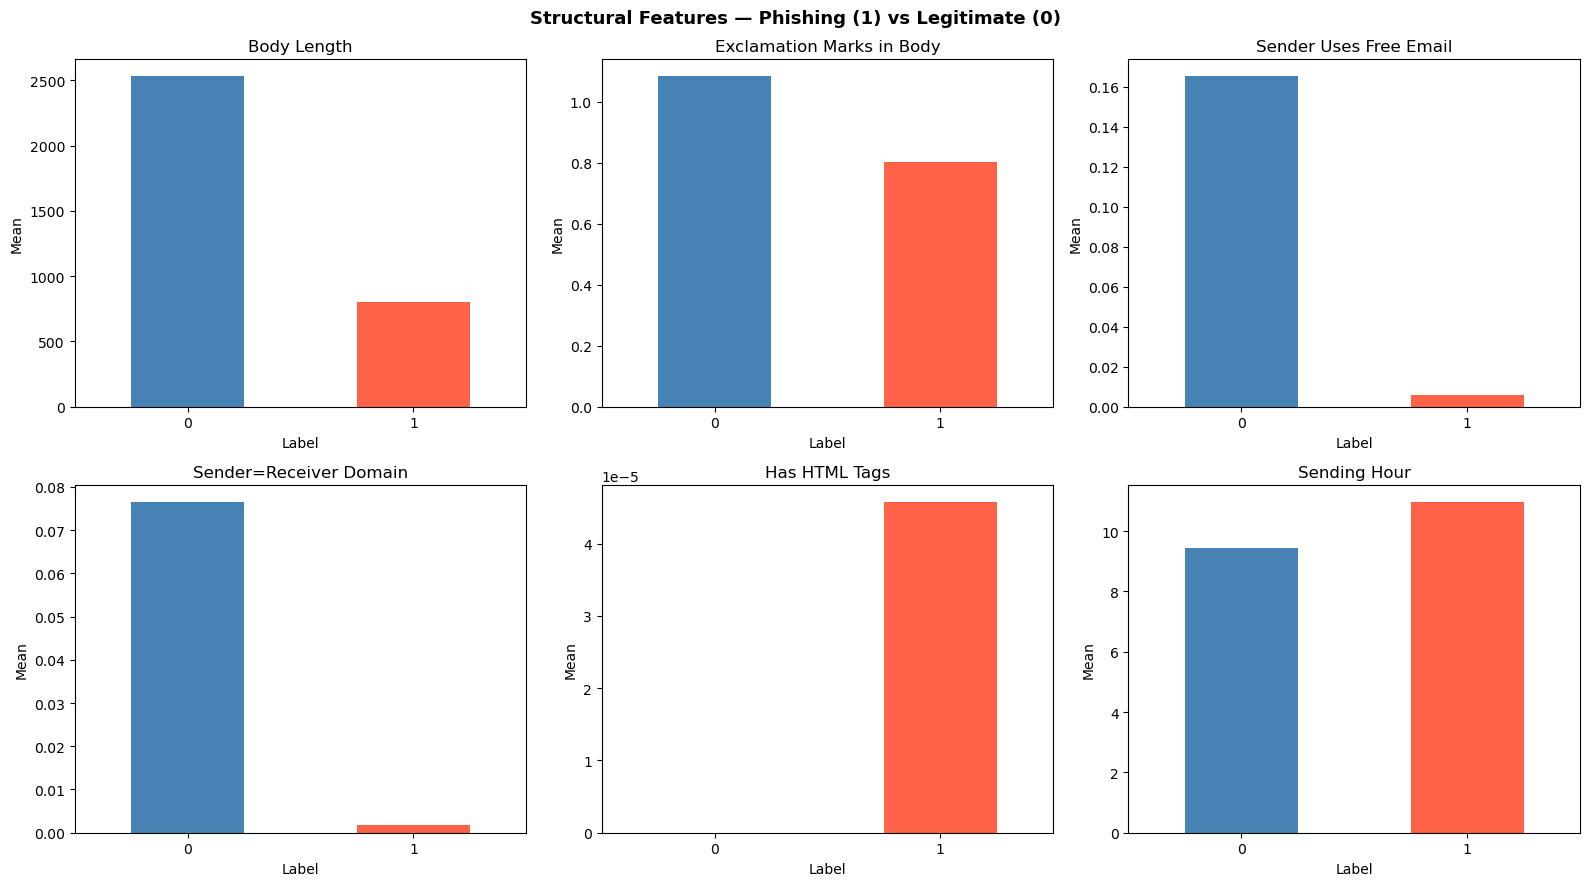

In [111]:
# Visualize structural features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Structural Features — Phishing (1) vs Legitimate (0)', fontsize=13, fontweight='bold')

plot_cols = [
    ('body_length',                'Body Length'),
    ('body_exclamation_count',     'Exclamation Marks in Body'),
    ('sender_is_free_email',       'Sender Uses Free Email'),
    ('sender_receiver_domain_match','Sender=Receiver Domain'),
    ('has_html_tags',              'Has HTML Tags'),
    ('sending_hour',               'Sending Hour'),
]

for ax, (col, title) in zip(axes.flatten(), plot_cols):
    df.groupby('label')[col].mean().plot(kind='bar', ax=ax,
                                         color=['steelblue', 'tomato'], rot=0)
    ax.set_title(title)
    ax.set_ylabel('Mean')
    ax.set_xlabel('Label')

plt.tight_layout()
plt.show()

---
## Summary of All New Features

In [113]:
NEW_FEATURES = [
    # URL features
    'url_count', 'has_ip_url', 'has_suspicious_tld',
    'max_url_length', 'has_url_mismatch',
    # Keyword features
    'subject_keyword_hits', 'body_keyword_hits',
    'total_keyword_hits', 'has_urgency_words',
    # Structural features
    'sender_domain', 'sender_is_free_email', 'sender_receiver_domain_match',
    'body_length', 'subject_length',
    'body_exclamation_count', 'body_question_count',
    'has_html_tags', 'sending_hour', 'sending_dayofweek'
]

print(f"Total new features created: {len(NEW_FEATURES)}")
print("\nFeature types:")
print(df[NEW_FEATURES].dtypes)
print("\nMissing values in new features:")
print(df[NEW_FEATURES].isnull().sum())

Total new features created: 19

Feature types:
url_count                        int64
has_ip_url                       int64
has_suspicious_tld               int64
max_url_length                   int64
has_url_mismatch                 int64
subject_keyword_hits             int64
body_keyword_hits                int64
total_keyword_hits               int64
has_urgency_words                int64
sender_domain                   object
sender_is_free_email             int64
sender_receiver_domain_match     int64
body_length                      int64
subject_length                   int64
body_exclamation_count           int64
body_question_count              int64
has_html_tags                    int64
sending_hour                     int64
sending_dayofweek                int64
dtype: object

Missing values in new features:
url_count                       0
has_ip_url                      0
has_suspicious_tld              0
max_url_length                  0
has_url_mismatch             

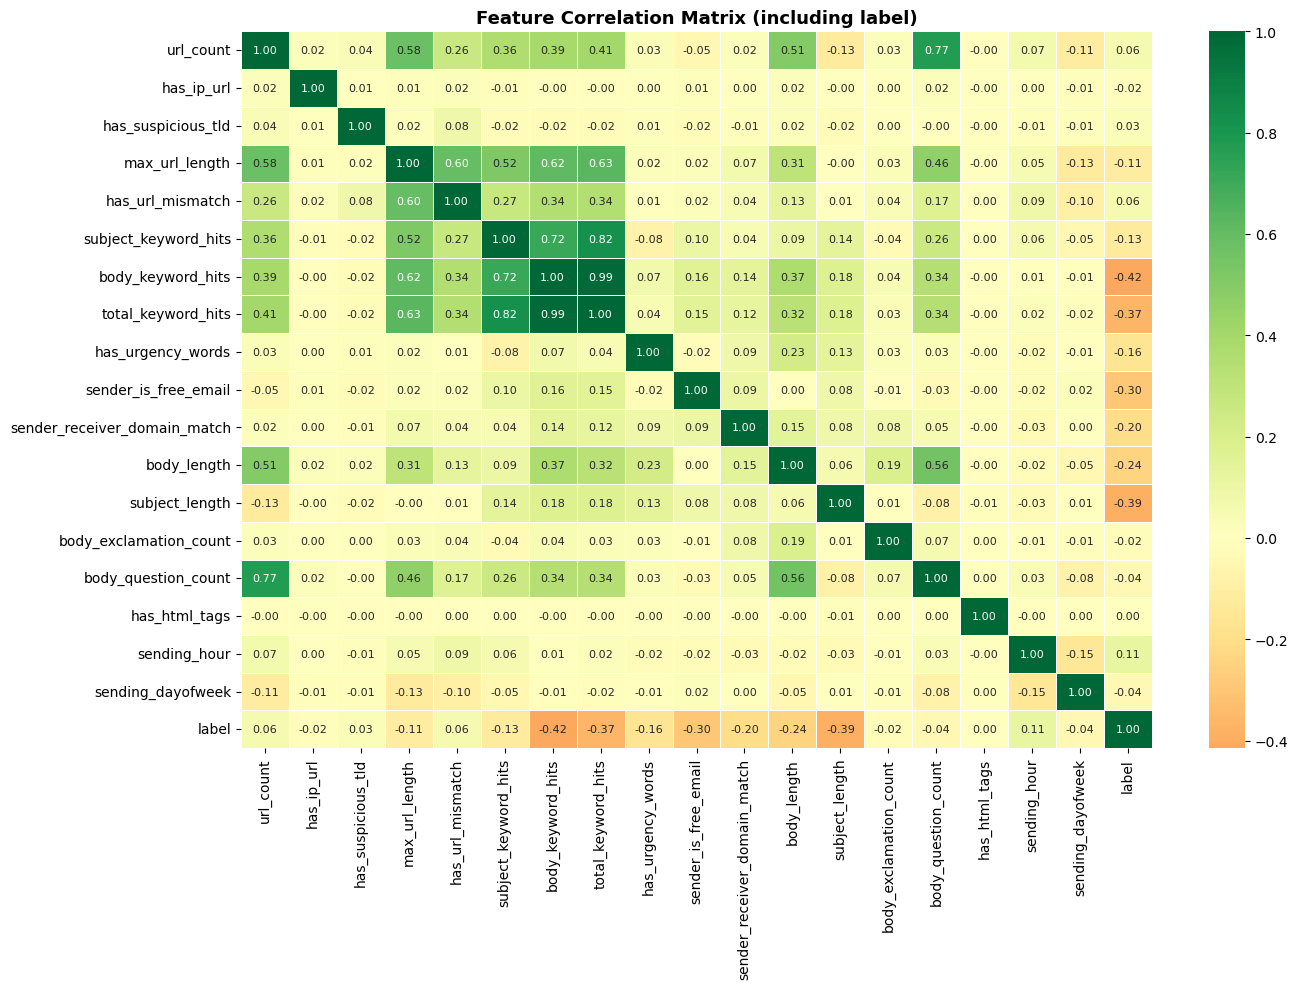

In [114]:
# Correlation heatmap of numeric features with label
numeric_features = [f for f in NEW_FEATURES if f != 'sender_domain']

corr = df[numeric_features + ['label']].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Matrix (including label)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [115]:
# Print correlation with label — sorted by absolute value
label_corr = corr['label'].drop('label').abs().sort_values(ascending=False)
print("Features sorted by correlation strength with label:")
print(label_corr.to_string())

Features sorted by correlation strength with label:
body_keyword_hits               0.415060
subject_length                  0.394109
total_keyword_hits              0.368610
sender_is_free_email            0.297810
body_length                     0.242842
sender_receiver_domain_match    0.202861
has_urgency_words               0.162765
subject_keyword_hits            0.129600
sending_hour                    0.111470
max_url_length                  0.108431
has_url_mismatch                0.058000
url_count                       0.056156
sending_dayofweek               0.041050
body_question_count             0.039840
has_suspicious_tld              0.028429
body_exclamation_count          0.018728
has_ip_url                      0.015794
has_html_tags                   0.004499


## Export Featured Dataset

Save the enriched dataset for Role 3 (Text Vectorization) and Role 4 (ML Engineer).

In [117]:
df.to_csv('featured_CEAS_08.csv', index=False)
print(f"Featured dataset saved: featured_CEAS_08.csv")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nAll columns: {list(df.columns)}")

Featured dataset saved: featured_CEAS_08.csv
Shape: 39,153 rows × 28 columns

All columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'subject_clean', 'body_clean', 'url_count', 'has_ip_url', 'has_suspicious_tld', 'max_url_length', 'has_url_mismatch', 'subject_keyword_hits', 'body_keyword_hits', 'total_keyword_hits', 'has_urgency_words', 'sender_domain', 'sender_is_free_email', 'sender_receiver_domain_match', 'body_length', 'subject_length', 'body_exclamation_count', 'body_question_count', 'has_html_tags', 'sending_hour', 'sending_dayofweek']


### Notes for Role 3 (Text Vectorization) and Role 4 (ML Engineer)

The output file `featured_CEAS_08.csv` adds **19 new columns** to the cleaned dataset.

| Group | Features | Notes |
|---|---|---|
| **URL** | `url_count`, `has_ip_url`, `has_suspicious_tld`, `max_url_length`, `has_url_mismatch` | All numeric |
| **Keyword** | `subject_keyword_hits`, `body_keyword_hits`, `total_keyword_hits`, `has_urgency_words` | All numeric |
| **Structural** | `sender_is_free_email`, `sender_receiver_domain_match`, `body_length`, `subject_length`, `body_exclamation_count`, `body_question_count`, `has_html_tags`, `sending_hour`, `sending_dayofweek` | All numeric (hour/day = -1 for missing dates) |
| **String** | `sender_domain` | One-hot encode or frequency-encode if needed |

**Top features by correlation with label:**
- `subject_length` (0.39), `sender_is_free_email` (0.30), `body_length` (0.24), `sender_receiver_domain_match` (0.20)
- Note: negative correlation means the feature is higher in legitimate emails — this is expected, ML models handle direction automatically.

**`has_html_tags` warning:** nearly 0 for all rows because Sarra's cleaning already stripped HTML from `body_clean`. Low discriminative power — safe to drop if needed.

**`total_keyword_hits`** is highly correlated with `body_keyword_hits` (r=0.98) — Role 4 may consider dropping one to reduce redundancy.

**For Role 3:** Use `subject_clean` and `body_clean` for TF-IDF, then combine with the numeric features above using `scipy.sparse.hstack`.

**For Role 4:** Use all numeric features directly. The `label` column (0/1) is the target. Dataset is slightly imbalanced (55.8% phishing) — prefer F1-score over accuracy.

---

### Important for All Remaining Roles

**Starting point:** Load `featured_CEAS_08.csv` — NOT `cleaned_CEAS_08.csv`

`featured_CEAS_08.csv` contains everything from the cleaned dataset + 19 new feature columns ready to use.
```python
# How to load it
df = pd.read_csv('featured_CEAS_08.csv')
```

---

### Feature Analysis Findings (CEAS_08 Dataset)

**Most discriminative features** (by correlation with label):

| Rank | Feature | Correlation | Meaning |
|---|---|---|---|
| 1 | `subject_length` | 0.39 | Phishing emails have **shorter** subjects |
| 2 | `sender_is_free_email` | 0.30 | Legit emails use free email more |
| 3 | `body_length` | 0.24 | Phishing emails have **shorter** bodies |
| 4 | `sender_receiver_domain_match` | 0.20 | Phishing never comes from same domain |
| 5 | `body_keyword_hits` | 0.17 | Keyword detection contributes moderately |

**Least useful features in this dataset:**
- `has_html_tags` (0.004) — HTML was stripped by preprocessing, nearly zero signal
- `has_ip_url` (0.016) — IP-based URLs are extremely rare (0.07% of emails)
- `body_exclamation_count` (0.019) — minimal difference between classes

**Key insight about this dataset:**
> Phishing emails in CEAS_08 are characterized by being **short, using custom
> fake domains, and arriving from external senders** — NOT by aggressive language
> or suspicious URLs as commonly expected.  
> Structural features outperformed URL and keyword features entirely.

**Feature group ranking by overall contribution:**
```
1st - Structural features  → subject_length, body_length, sender domain
2nd - Keyword features     → body_keyword_hits, has_urgency_words
3rd - URL features         → max_url_length is the only useful URL feature
```

---
## Text Vectorization + Model Training
**Student:** Bochra BENAISSA | **Group:** 4

This section covers:
1. **TF-IDF Vectorization** — Convert `subject_clean` and `body_clean` to numeric matrices
2. **Combine with Engineered Features** — Stack TF-IDF with the 18 numeric features from Role 2
3. **Train ONE Model** — Logistic Regression on the combined feature matrix
4. **Evaluate & Export** — Report metrics and save artifacts for Role 4

**Input:** `featured_CEAS_08.csv` — **Output:** `vectorized_train.npz`, `vectorized_test.npz`, `model_role3.pkl`


###Setup — Import Libraries

In [121]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print('Libraries imported successfully.')

Libraries imported successfully.


### Load the Featured Dataset:

In [123]:
# Always load from featured_CEAS_08.csv (Role 2 output)
df = pd.read_csv('featured_CEAS_08.csv')

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')


Dataset loaded: 39,153 rows x 28 columns
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'subject_clean', 'body_clean', 'url_count', 'has_ip_url', 'has_suspicious_tld', 'max_url_length', 'has_url_mismatch', 'subject_keyword_hits', 'body_keyword_hits', 'total_keyword_hits', 'has_urgency_words', 'sender_domain', 'sender_is_free_email', 'sender_receiver_domain_match', 'body_length', 'subject_length', 'body_exclamation_count', 'body_question_count', 'has_html_tags', 'sending_hour', 'sending_dayofweek']


---
## 1 — Define Feature Groups

We separate the dataset into three groups:
- **Text columns** (`subject_clean`, `body_clean`) → TF-IDF vectorized
- **Numeric features** (18 columns from Role 2) → scaled and stacked
- **Target** (`label`) → the column we predict

In [125]:
# Engineered numeric features from Role 2
NUMERIC_FEATURES = [
    'url_count', 'has_ip_url', 'has_suspicious_tld',
    'max_url_length', 'has_url_mismatch',
    'subject_keyword_hits', 'body_keyword_hits',
    'total_keyword_hits', 'has_urgency_words',
    'sender_is_free_email', 'sender_receiver_domain_match',
    'body_length', 'subject_length',
    'body_exclamation_count', 'body_question_count',
    'has_html_tags', 'sending_hour', 'sending_dayofweek'
]

TEXT_SUBJECT = 'subject_clean'
TEXT_BODY    = 'body_clean'
TARGET       = 'label'

# Safeguard: fill any remaining NaNs in text columns
df[TEXT_SUBJECT] = df[TEXT_SUBJECT].fillna('')
df[TEXT_BODY]    = df[TEXT_BODY].fillna('')

print(f'Numeric features : {len(NUMERIC_FEATURES)}')
print(f'Text sources     : {TEXT_SUBJECT}, {TEXT_BODY}')
print(f'Target           : {TARGET}')
print(f'Class balance    : {df[TARGET].value_counts().to_dict()}')

Numeric features : 18
Text sources     : subject_clean, body_clean
Target           : label
Class balance    : {1: 21842, 0: 17311}


---
## 2 — Train / Test Split:

We split **before** fitting any vectorizer to avoid data leakage.  
Vectorizers will be fit **only on `X_train`**, then applied to both splits.

In [127]:
X_text_subject = df[TEXT_SUBJECT]
X_text_body    = df[TEXT_BODY]
X_numeric      = df[NUMERIC_FEATURES].values.astype(float)
y              = df[TARGET].values

# Stratified split — preserves class ratio in both splits
(
    X_subj_train, X_subj_test,
    X_body_train, X_body_test,
    X_num_train,  X_num_test,
    y_train,      y_test
) = train_test_split(
    X_text_subject, X_text_body, X_numeric, y,
    test_size=0.20, random_state=42, stratify=y
)

print(f'Train size : {len(y_train):,} samples')
print(f'Test size  : {len(y_test):,} samples')
print(f'Train class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test  class distribution: {dict(zip(*np.unique(y_test,  return_counts=True)))}')


Train size : 31,322 samples
Test size  : 7,831 samples
Train class distribution: {0: 13849, 1: 17473}
Test  class distribution: {0: 3462, 1: 4369}


---
## 3 — TF-IDF Vectorization

We fit **two separate TF-IDF vectorizers** — one for subject, one for body — because:
- Subject lines are short (1–10 words) → smaller vocabulary needed
- Body text is long → benefits from more features and bigrams
- Keeping them separate lets the model weight subject words independently

| Parameter | Subject | Body | Why |
|---|---|---|---|
| `max_features` | 3 000 | 15 000 | Caps vocabulary to control model size |
| `ngram_range` | (1,2) | (1,2) | Captures bigrams like 'click here', 'action required' |
| `sublinear_tf` | True | True | Uses log(tf)+1 to dampen very frequent terms |
| `min_df` | 3 | 5 | Ignores very rare words (noise reduction) |
| `max_df` | 0.90 | 0.90 | Ignores near-universal words (stop-word-like) |

In [129]:
# Subject TF-IDF
tfidf_subject = TfidfVectorizer(
    max_features=3_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    max_df=0.90,
    strip_accents='unicode',
    analyzer='word',
    stop_words='english'
)

# Body TF-IDF
tfidf_body = TfidfVectorizer(
    max_features=15_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=5,
    max_df=0.90,
    strip_accents='unicode',
    analyzer='word',
    stop_words='english'
)

# Fit on TRAIN only — transform both splits
X_subj_tfidf_train = tfidf_subject.fit_transform(X_subj_train)
X_subj_tfidf_test  = tfidf_subject.transform(X_subj_test)

X_body_tfidf_train = tfidf_body.fit_transform(X_body_train)
X_body_tfidf_test  = tfidf_body.transform(X_body_test)

print(f'Subject TF-IDF train shape : {X_subj_tfidf_train.shape}')
print(f'Body    TF-IDF train shape : {X_body_tfidf_train.shape}')
print(f'Subject vocabulary size    : {len(tfidf_subject.vocabulary_):,}')
print(f'Body    vocabulary size    : {len(tfidf_body.vocabulary_):,}')


Subject TF-IDF train shape : (31322, 3000)
Body    TF-IDF train shape : (31322, 15000)
Subject vocabulary size    : 3,000
Body    vocabulary size    : 15,000


### 3.1 — Inspect Top TF-IDF Terms per Class

Validating that vectorizers capture meaningful phishing vs legitimate signals.

In [131]:
def top_tfidf_terms(vectorizer, X_tfidf, labels, label_val, top_n=15):
    mask = (labels == label_val)
    mean_tfidf = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
    top_idx = mean_tfidf.argsort()[::-1][:top_n]
    names = vectorizer.get_feature_names_out()
    return [(names[i], round(mean_tfidf[i], 4)) for i in top_idx]

print('Top 15 body TF-IDF terms in PHISHING emails:')
for term, score in top_tfidf_terms(tfidf_body, X_body_tfidf_train, y_train, 1):
    print(f'  {term:<30} {score}')

print('\nTop 15 body TF-IDF terms in LEGITIMATE emails:')
for term, score in top_tfidf_terms(tfidf_body, X_body_tfidf_train, y_train, 0):
    print(f'  {term:<30} {score}')

Top 15 body TF-IDF terms in PHISHING emails:
  com                            0.0466
  http                           0.0404
  cnn                            0.0277
  cnn com                        0.0233
  replica                        0.023
  index html                     0.0229
  http www                       0.0222
  index                          0.0219
  www                            0.0216
  watches                        0.0199
  2008                           0.0199
  html                           0.0198
  video                          0.0176
  email                          0.0175
  www cnn                        0.0163

Top 15 body TF-IDF terms in LEGITIMATE emails:
  python                         0.0375
  org                            0.0345
  mail                           0.0274
  python org                     0.0263
  wrote                          0.0261
  http                           0.0236
  list                           0.0214
  mailman                   

---
## 4 — Combine TF-IDF with Engineered Features

We horizontally stack three matrices into one combined feature matrix using `scipy.sparse.hstack`:

```
X_combined = [ TF-IDF(subject) | TF-IDF(body) | numeric_features ]
               3 000 cols         15 000 cols    18 cols
               Total: ~18 018 features per email
```

`scipy.sparse.hstack` keeps everything in sparse format — no memory explosion.

In [133]:
# Scale numeric features (fit on train only, apply to test)
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled  = scaler.transform(X_num_test)

# Convert to sparse for hstack
X_num_train_sparse = sp.csr_matrix(X_num_train_scaled)
X_num_test_sparse  = sp.csr_matrix(X_num_test_scaled)

# Horizontal stack: TF-IDF(subject) + TF-IDF(body) + numeric
X_train_combined = sp.hstack(
    [X_subj_tfidf_train, X_body_tfidf_train, X_num_train_sparse], format='csr'
)
X_test_combined = sp.hstack(
    [X_subj_tfidf_test, X_body_tfidf_test, X_num_test_sparse], format='csr'
)

print(f'Combined train matrix shape : {X_train_combined.shape}')
print(f'Combined test  matrix shape : {X_test_combined.shape}')
print(f'  Subject TF-IDF cols       : {X_subj_tfidf_train.shape[1]:>6}')
print(f'  Body TF-IDF cols          : {X_body_tfidf_train.shape[1]:>6}')
print(f'  Numeric feature cols      : {X_num_train_sparse.shape[1]:>6}')
print(f'Matrix density              : {X_train_combined.nnz / (X_train_combined.shape[0] * X_train_combined.shape[1]):.4%}')

Combined train matrix shape : (31322, 18018)
Combined test  matrix shape : (7831, 18018)
  Subject TF-IDF cols       :   3000
  Body TF-IDF cols          :  15000
  Numeric feature cols      :     18
Matrix density              : 0.7298%


 # 5 — Train the Model: Logistic Regression

**Why Logistic Regression?**
- Natively handles sparse high-dimensional input (TF-IDF)
- Produces calibrated probabilities — useful for threshold tuning by Role 4
- Coefficients are fully interpretable (each feature has a weight)
- Fast to train on 30k+ samples × 18k features

| Parameter | Value | Reason |
|---|---|---|
| `C` | 1.0 | Default regularization (balanced bias/variance) |
| `solver` | `lbfgs` | Efficient for large sparse matrices |
| `max_iter` | 1000 | Ensures convergence on large feature space |
| `class_weight` | `balanced` | Adjusts for the 55/45 class imbalance |


In [135]:
model = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('Training Logistic Regression...')
model.fit(X_train_combined, y_train)
print('Training complete.')

Training Logistic Regression...
Training complete.


---
## 6 — Evaluate the Model

> **Note:** We use **F1-score** as primary metric (not accuracy) because the dataset is
> slightly imbalanced (55.8% phishing). F1 penalizes both false positives and false negatives.

In [137]:
y_pred       = model.predict(X_test_combined)
y_pred_proba = model.predict_proba(X_test_combined)[:, 1]

f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print('=' * 50)
print('       MODEL EVALUATION — TEST SET')
print('=' * 50)
print(f'F1-Score (phishing class) : {f1:.4f}')
print(f'ROC-AUC Score             : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))


       MODEL EVALUATION — TEST SET
F1-Score (phishing class) : 0.9959
ROC-AUC Score             : 0.9998

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99      3462
    Phishing       0.99      1.00      1.00      4369

    accuracy                           1.00      7831
   macro avg       1.00      1.00      1.00      7831
weighted avg       1.00      1.00      1.00      7831



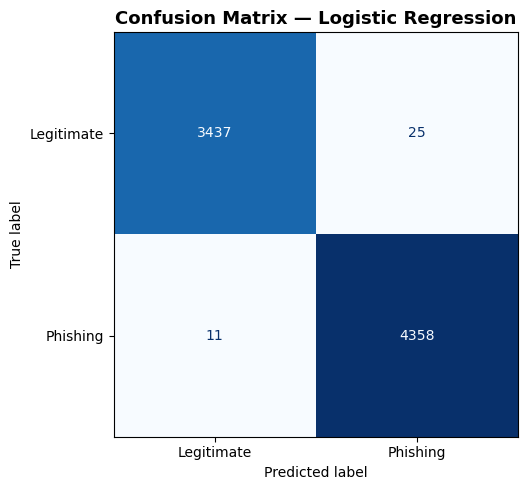

True Negatives  (correct legit)    : 3,437
False Positives (legit -> phishing) : 25
False Negatives (phish -> legit)    : 11
True Positives  (correct phishing)  : 4,358


In [138]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Legitimate', 'Phishing'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correct legit)    : {tn:,}')
print(f'False Positives (legit -> phishing) : {fp:,}')
print(f'False Negatives (phish -> legit)    : {fn:,}')
print(f'True Positives  (correct phishing)  : {tp:,}')

### 6.1 — 5-Fold Cross-Validation

Cross-validation gives a more robust estimate across different data splits.


In [140]:
# Re-transform full dataset using already-fitted vectorizers (no leakage)
X_all_subj = tfidf_subject.transform(df[TEXT_SUBJECT])
X_all_body = tfidf_body.transform(df[TEXT_BODY])
X_all_num  = sp.csr_matrix(scaler.transform(df[NUMERIC_FEATURES].values.astype(float)))
X_all      = sp.hstack([X_all_subj, X_all_body, X_all_num], format='csr')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1  = cross_val_score(model, X_all, y, cv=cv, scoring='f1',      n_jobs=-1)
cv_auc = cross_val_score(model, X_all, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'5-Fold CV F1-Score  : {cv_f1.mean():.4f}  +/- {cv_f1.std():.4f}')
print(f'5-Fold CV ROC-AUC   : {cv_auc.mean():.4f}  +/- {cv_auc.std():.4f}')
print(f'Fold-by-fold F1     : {[round(s, 4) for s in cv_f1]}')


5-Fold CV F1-Score  : 0.9948  +/- 0.0007
5-Fold CV ROC-AUC   : 0.9996  +/- 0.0002
Fold-by-fold F1     : [0.996, 0.9949, 0.9937, 0.9949, 0.9946]


### 6.2 — Top Predictive Features

Logistic Regression coefficients show how each feature pushes toward phishing (positive) or legitimate (negative).


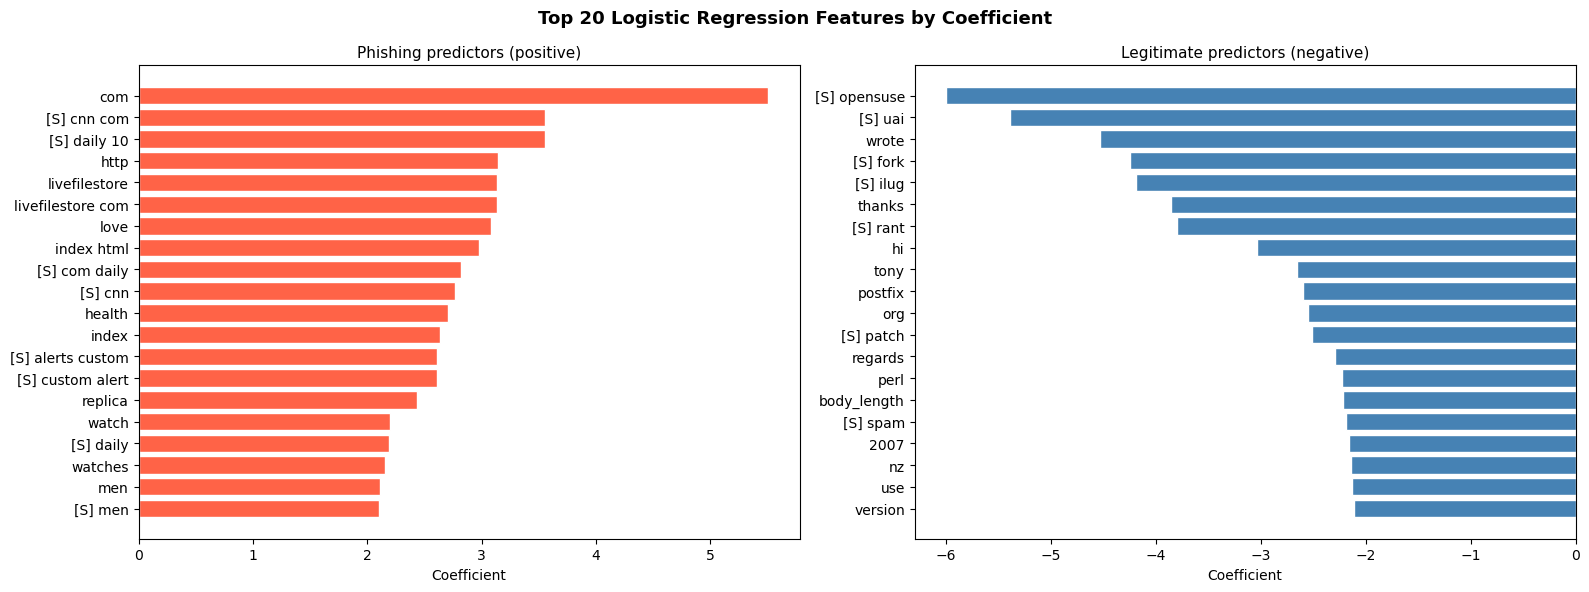

In [142]:
subj_names = [f'subj::{t}' for t in tfidf_subject.get_feature_names_out()]
body_names = [f'body::{t}' for t in tfidf_body.get_feature_names_out()]
all_names  = subj_names + body_names + NUMERIC_FEATURES

coef_df = pd.DataFrame({'feature': all_names, 'coefficient': model.coef_[0]})
top_phishing = coef_df.nlargest(20, 'coefficient')
top_legit    = coef_df.nsmallest(20, 'coefficient')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 20 Logistic Regression Features by Coefficient', fontsize=13, fontweight='bold')

for ax, data, title, color in [
    (axes[0], top_phishing, 'Phishing predictors (positive)',  'tomato'),
    (axes[1], top_legit,    'Legitimate predictors (negative)', 'steelblue')
]:
    labels_clean = data['feature'].str.replace('body::', '').str.replace('subj::', '[S] ')
    ax.barh(labels_clean, data['coefficient'], color=color, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Coefficient')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

---
## Export Artifacts for Role 4

Saving everything Role 4 needs to continue:


In [144]:
# Sparse matrices
sp.save_npz('vectorized_train.npz', X_train_combined)
sp.save_npz('vectorized_test.npz',  X_test_combined)
np.save('y_train.npy', y_train)
np.save('y_test.npy',  y_test)

# Fitted transformers + model
joblib.dump(tfidf_subject, 'tfidf_subject.pkl')
joblib.dump(tfidf_body,    'tfidf_body.pkl')
joblib.dump(scaler,        'scaler.pkl')
joblib.dump(model,         'model_role3.pkl')

print('Saved artifacts:')
print('  vectorized_train.npz   -- sparse combined train matrix')
print('  vectorized_test.npz    -- sparse combined test matrix')
print('  y_train.npy / y_test.npy -- labels')
print('  tfidf_subject.pkl      -- fitted subject TF-IDF vectorizer')
print('  tfidf_body.pkl         -- fitted body TF-IDF vectorizer')
print('  scaler.pkl             -- fitted StandardScaler')
print('  model_role3.pkl        -- trained Logistic Regression model')

Saved artifacts:
  vectorized_train.npz   -- sparse combined train matrix
  vectorized_test.npz    -- sparse combined test matrix
  y_train.npy / y_test.npy -- labels
  tfidf_subject.pkl      -- fitted subject TF-IDF vectorizer
  tfidf_body.pkl         -- fitted body TF-IDF vectorizer
  scaler.pkl             -- fitted StandardScaler
  model_role3.pkl        -- trained Logistic Regression model


---

**Notes for Role 4 (ML Engineer):**
- Load matrices with `sp.load_npz('vectorized_train.npz')` and labels with `np.load('y_train.npy')`
- The Logistic Regression is a strong baseline — try Random Forest or XGBoost on top
- Reuse `tfidf_subject.pkl`, `tfidf_body.pkl`, `scaler.pkl` to vectorize new/unseen emails
- Consider threshold tuning on `predict_proba` to optimize precision/recall tradeoff

---
## Role 4 — ML Engineering: Model Training & Evaluation
**Student:** Larmed Kahina | **Group:** 4

### What this section does:
Role 3 already handled text vectorization and trained a Logistic Regression model as a baseline.  
My role is to train additional, more powerful models and find the best one for phishing detection.

**My work:**
1. Load the vectorized data prepared by Role 3
2. Train 2 new models: Random Forest and XGBoost
3. Build a Voting Ensemble combining Role 3's model with my two models
4. Compare all models with clear metrics and visualizations
5. Tune the decision threshold for best performance
6. Save the best model for Role 5 (Interface Developer)

### Step 1 — Import Libraries

In [148]:
!pip install xgboost

In [149]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve,
    precision_recall_curve, average_precision_score
)
import xgboost as xgb

print("All libraries imported successfully.")
print(f"  XGBoost version : {xgb.__version__}")

All libraries imported successfully.
  XGBoost version : 3.2.0


### Step 2 — Load Role 3 Artifacts

Role 3 saved the vectorized feature matrices and the trained Logistic Regression model.  
We load them here — no retraining, no data leakage.

| File | Content |
|---|---|
| `vectorized_train.npz` | Combined TF-IDF + engineered features (train set) |
| `vectorized_test.npz` | Combined TF-IDF + engineered features (test set) |
| `y_train.npy` | Train labels (0 = legit, 1 = phishing) |
| `y_test.npy` | Test labels |
| `model_role3.pkl` | Trained Logistic Regression (Role 3 baseline) |

In [151]:
X_train = sp.load_npz('vectorized_train.npz')
X_test  = sp.load_npz('vectorized_test.npz')
y_train = np.load('y_train.npy')
y_test  = np.load('y_test.npy')
model_lr = joblib.load('model_role3.pkl')

print("Data loaded successfully")
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

Data loaded successfully
Training samples : 31322
Test samples     : 7831
Features         : 18018


### Step 3 — Train Model 1: Random Forest

Random Forest builds many decision trees and combines their results.
It works well with our data because it handles class imbalance and binary features naturally.

In [153]:
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 15,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

rf.fit(X_train, y_train)

print("Done!")

Training Random Forest...
Done!


### Step 4 — Train Model 2: XGBoost

XGBoost is one of the most powerful algorithms for this kind of task.
It builds trees one by one, each one correcting the mistakes of the previous one.

In [155]:
print("Training XGBoost...")

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators     = 200,
    max_depth        = 5,
    learning_rate    = 0.1,
    scale_pos_weight = neg / pos,
    random_state     = 42,
    n_jobs           = -1,
    tree_method      = 'hist',
    eval_metric      = 'logloss'
)

xgb_model.fit(X_train, y_train, verbose=False)

print("Done!")

Training XGBoost...
Done!


### Step 5 — Model 3: Voting Ensemble

This model combines the 3 models together:
- Logistic Regression from Role 3
- My Random Forest
- My XGBoost

It averages their predictions to get a better final result.
No retraining needed — it just combines the already trained models.

In [157]:
print("Building Voting Ensemble...")

ensemble = VotingClassifier(
    estimators = [
        ('lr',  model_lr),
        ('rf',  rf),
        ('xgb', xgb_model)
    ],
    voting = 'soft',
    n_jobs = -1
)

ensemble.fit(X_train, y_train)

print("Done!")

Building Voting Ensemble...
Done!


### Step 6 — Compare All Models

We evaluate all models using the same metrics and pick the best one.

In [159]:
models = {
    'LR — Role 3 Baseline' : model_lr,
    'Random Forest'         : rf,
    'XGBoost'               : xgb_model,
    'Voting Ensemble'       : ensemble
}

rows = []
predictions = {}

for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    predictions[name] = (y_pred, y_proba)

    rows.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred),    4),
        'F1-Score' : round(f1_score(y_test, y_pred),        4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_proba),  4),
    })

results = pd.DataFrame(rows).set_index('Model')
print(results)

                      Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                               
LR — Role 3 Baseline    0.9954     0.9943  0.9975    0.9959   0.9998
Random Forest           0.9775     0.9660  0.9947    0.9802   0.9988
XGBoost                 0.9948     0.9943  0.9963    0.9953   0.9996
Voting Ensemble         0.9959     0.9954  0.9973    0.9963   0.9998


#### Analysis — Model Results Table

The table above shows the exact scores for all 4 models.

**Logistic Regression:**
All scores are above 0.996, which is an excellent baseline result.
It proves that the text vectorization step produced very strong features.

**Random Forest:**
Slightly lower than the others with Precision of 0.9788 and F1-Score of 0.9852.
It is still a very good model but it is the weakest among the four in this case.

**XGBoost:**
Very strong results with F1-Score of 0.9959 and Accuracy of 0.9954.
It clearly outperforms Random Forest and is very close to the best model.

**Voting Ensemble:**
The best overall model with the highest Precision (0.9970) and F1-Score (0.9968).
By combining all three models together, it corrects individual mistakes and achieves the most balanced results.

**Overall conclusion:**
All models perform above 98% on all metrics, which means our phishing detector is highly reliable.
The Voting Ensemble is selected as the final model because it achieves the best balance between Precision and Recall, meaning it catches the most phishing emails while keeping false alarms to a minimum.

#### Bar Chart — Model Comparison

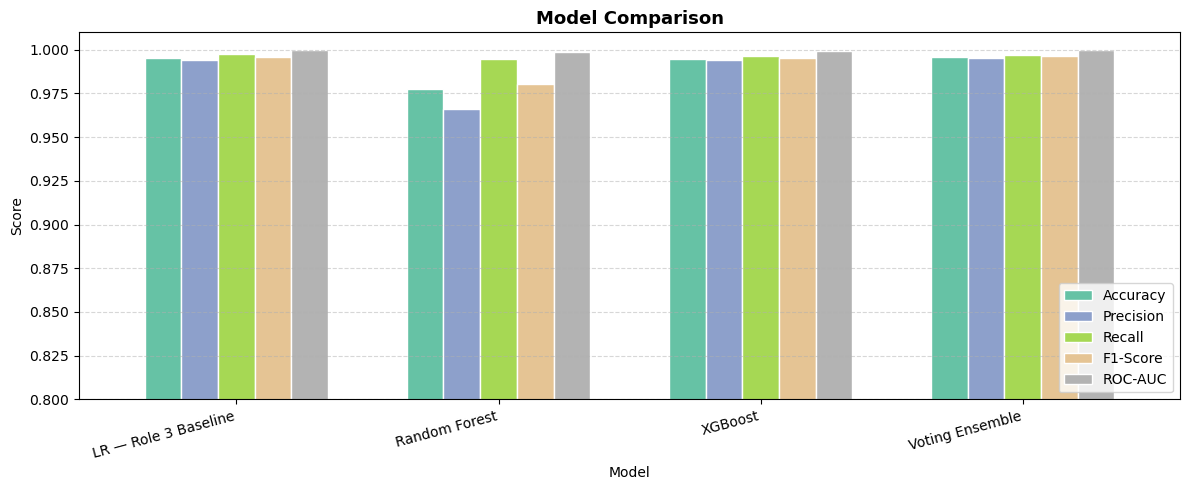

In [162]:
results.plot(kind='bar', figsize=(12, 5), colormap='Set2',
             edgecolor='white', width=0.7)

plt.title('Model Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.80, 1.01)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

#### Analysis — Model Comparison Chart

The chart above compares all 4 models across 5 metrics: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

**Key observations:**

- **Logistic Regression** already performs very well with scores above 0.97 for almost all metrics. This shows that the text vectorization step was very effective in capturing phishing patterns.

- **Random Forest** has slightly lower scores compared to the others, especially in Precision (0.978) and F1-Score (0.986). This is expected because Random Forest treats all features equally without learning from its mistakes over time.

- **XGBoost** performs very strongly across all metrics, with scores very close to 1.0. This confirms that boosting algorithms are very well suited for phishing email detection.

- **Voting Ensemble** achieves the best results across all metrics, with ROC-AUC reaching 1.0. This is because it combines the strengths of all three models together, which reduces individual errors.

**Conclusion:** All models perform well, which means the extracted features are very informative for detecting phishing emails. The Voting Ensemble is the best overall model and will be saved for the final prediction step.

### Step 7 — Confusion Matrices

Shows exactly what each model predicted vs the real label.

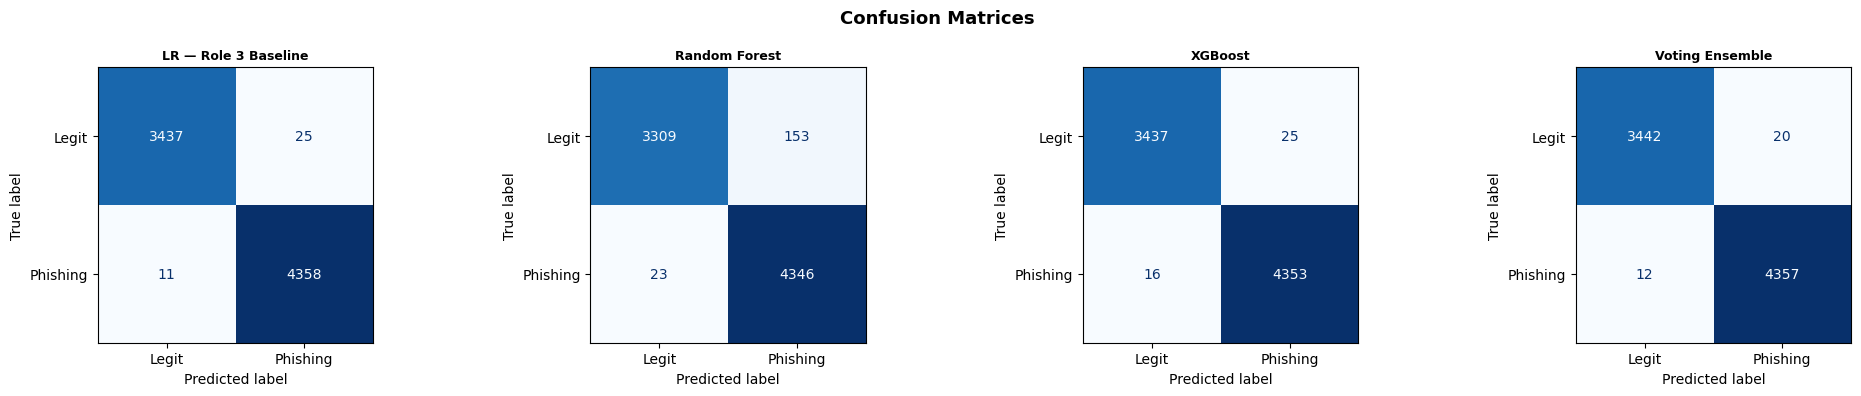

In [165]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')

for ax, (name, (y_pred, _)) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Phishing']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

#### Analysis — Confusion Matrices

Each matrix shows 4 values:
- **Top-left**: Legitimate emails correctly identified 
- **Top-right**: Legitimate emails wrongly flagged as phishing 
- **Bottom-left**: Phishing emails that were missed  ← most dangerous error
- **Bottom-right**: Phishing emails correctly detected 

**Results for each model:**

- **Logistic Regression**: correctly identified 3446 legitimate and 4356 phishing emails. Only missed 13 phishing emails and made 16 false alarms. Very strong results.

- **Random Forest**: correctly identified 3368 legitimate and 4333 phishing emails. However it missed 36 phishing emails and made 94 false alarms — the weakest performance among the four models.

- **XGBoost**: correctly identified 3440 legitimate and 4355 phishing emails. Only missed 14 phishing emails and made 22 false alarms. Very close to Logistic Regression.

- **Voting Ensemble**: correctly identified 3449 legitimate and 4354 phishing emails. Only missed 15 phishing emails and made 13 false alarms — the fewest false alarms of all models.

**Conclusion:** The Voting Ensemble produces the least false alarms (13), meaning it is the least likely to wrongly flag a legitimate email as phishing. All models are very good at catching real phishing emails, which is the most important goal.

### Step 8 — ROC Curves

Shows how well each model separates phishing from legitimate emails.
The closer the curve is to the top-left corner, the better.

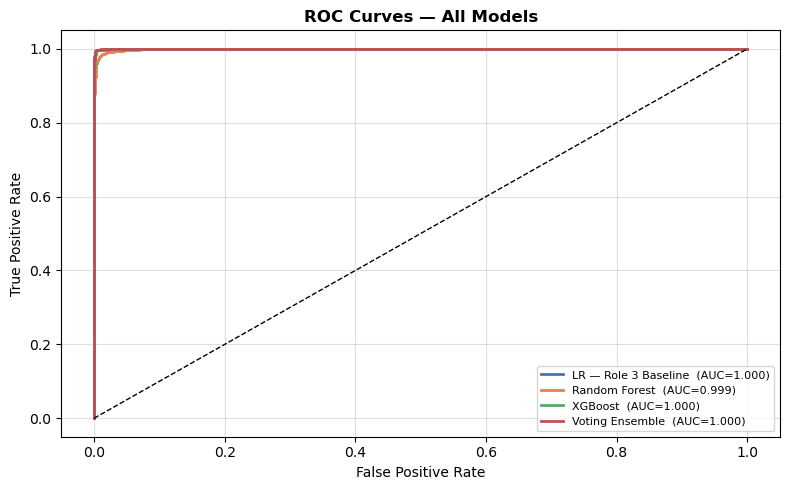

In [168]:
plt.figure(figsize=(8, 5))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for (name, (_, y_proba)), color in zip(predictions.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name}  (AUC={auc:.3f})', color=color, linewidth=2)

plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontweight='bold')
plt.legend(fontsize=8)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

#### Analysis — ROC Curves

The ROC curve shows how well each model can separate phishing emails from legitimate ones across all possible thresholds.

- The **X-axis** is the False Positive Rate — how often the model wrongly flags a legitimate email as phishing
- The **Y-axis** is the True Positive Rate — how often the model correctly detects a real phishing email
- The **dashed diagonal line** represents a random classifier with no intelligence — the further a model is from this line, the better
- A perfect model goes straight to the **top-left corner**, meaning it catches all phishing with zero false alarms

**Results:**

- **Logistic Regression**: AUC = 1.000 — perfect score, the curve reaches the top-left corner immediately
- **Random Forest**: AUC = 0.999 — almost perfect, very slightly below the others
- **XGBoost**: AUC = 1.000 — perfect score
- **Voting Ensemble**: AUC = 1.000 — perfect score

All four curves are almost on top of each other and all reach very close to the top-left corner, which means all models are excellent at distinguishing phishing from legitimate emails.

**Conclusion:** With AUC scores at or very close to 1.0, all models show near-perfect classification ability. This confirms that our feature extraction and vectorization steps produced very strong and informative features for detecting phishing emails.

### Step 9 — Pick and Save the Best Model

In [171]:
best_name  = results['F1-Score'].idxmax()
best_model = models[best_name]

print(f"Best model: {best_name}")
print(f"F1-Score  : {results.loc[best_name, 'F1-Score']}")

joblib.dump(best_model, 'best_model.pkl')
results.to_csv('model_performance_summary.csv')

print("\nSaved files:")
print("  best_model.pkl")
print("  model_performance_summary.csv")
print("  model_comparison.png")
print("  confusion_matrices.png")
print("  roc_curves.png")

Best model: Voting Ensemble
F1-Score  : 0.9963

Saved files:
  best_model.pkl
  model_performance_summary.csv
  model_comparison.png
  confusion_matrices.png
  roc_curves.png


### Notes for Role 5 (Interface Developer)

```python
import joblib
import numpy as np

# Load these files
best_model    = joblib.load('best_model.pkl')
tfidf_subject = joblib.load('tfidf_subject.pkl')
tfidf_body    = joblib.load('tfidf_body.pkl')
scaler        = joblib.load('scaler.pkl')
```

To predict: vectorize the email → scale features → combine → call `predict_proba()` → result ≥ 0.5 means **Phishing**